In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


dataset = pd.read_csv("datasets/Heart_Disease_Prediction.csv")
dataset.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### Preprocessing the Data

In [3]:
dataset.isnull().values.any()

False

In [4]:
missing_values = dataset.isnull().sum()
missing_values

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()

dataset["Heart Disease"] = encoder.fit_transform(dataset["Heart Disease"])
dataset.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### Viewing the Data

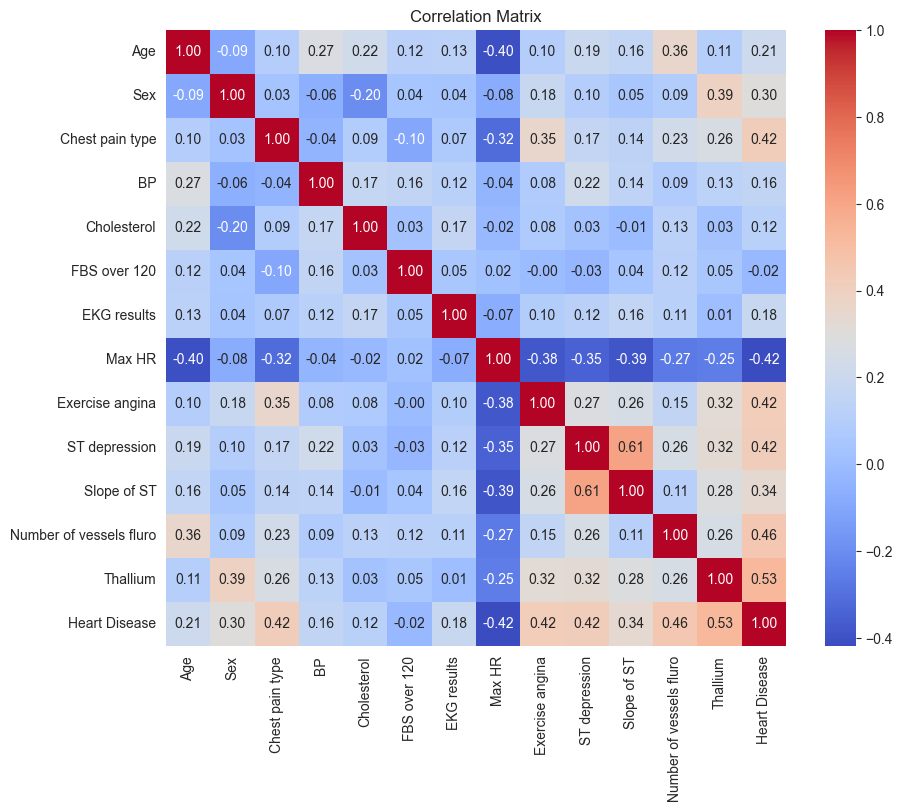

In [6]:
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [7]:
X = dataset.drop("Heart Disease", axis=1)
y = dataset["Heart Disease"]

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def analyze_model(model_name, y_test, y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_pred)

  print(f"\n{model_name} Model Performance:")
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1-Score:", f1)
  print("ROC AUC:", roc_auc)

### Testing the Logistic Regression Model

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(random_state=0, max_iter=1200)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("Logistic Regression Model Evaluation:")
print(classification_report(y_test, y_pred))

analyze_model("Logistic Regression", y_test, y_pred)

Logistic Regression Model Evaluation:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54


Logistic Regression Model Performance:
Accuracy: 0.9259259259259259
Precision: 0.9473684210526315
Recall: 0.8571428571428571
F1-Score: 0.9
ROC AUC: 0.9134199134199135


### ANN Classification

In [10]:
from sklearn.neural_network import MLPClassifier


mlp_regressor = MLPClassifier(hidden_layer_sizes=(27,), activation="relu", solver="lbfgs", random_state=42, max_iter=2000)

mlp_regressor.fit(X_train, y_train)
y_pred_mlp = mlp_regressor.predict(X_test)

print("MLP Regression Model Evaluation:")
print(classification_report(y_test, y_pred_mlp))

analyze_model("MLP Regression", y_test, y_pred_mlp)

MLP Regression Model Evaluation:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54


MLP Regression Model Performance:
Accuracy: 0.9259259259259259
Precision: 0.9473684210526315
Recall: 0.8571428571428571
F1-Score: 0.9
ROC AUC: 0.9134199134199135


### XGBoost

In [102]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(random_state=42, n_estimators=40, booster="gblinear")

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Model Evaluation:")
print(classification_report(y_test, y_pred_xgb))

analyze_model("XGBoost", y_test, y_pred_xgb)  

XGBoost Model Evaluation:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        33
           1       1.00      0.81      0.89        21

    accuracy                           0.93        54
   macro avg       0.95      0.90      0.92        54
weighted avg       0.93      0.93      0.92        54


XGBoost Model Performance:
Accuracy: 0.9259259259259259
Precision: 1.0
Recall: 0.8095238095238095
F1-Score: 0.8947368421052632
ROC AUC: 0.9047619047619048


### AdaBoost

In [138]:
from sklearn.ensemble import AdaBoostClassifier


adb_classifier = AdaBoostClassifier(n_estimators=40, algorithm="SAMME", random_state=42, learning_rate=0.6)

adb_classifier.fit(X_train, y_train)
y_pred_abc = adb_classifier.predict(X_test)

print("AdaBoost Classifier Evaluation:\n------------------------------")
print(classification_report(y_test, y_pred_abc))

analyze_model("AdaBoost Classifier", y_test, y_pred_abc)

AdaBoost Classifier Evaluation:
------------------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54


AdaBoost Classifier Model Performance:
Accuracy: 0.9074074074074074
Precision: 0.9444444444444444
Recall: 0.8095238095238095
F1-Score: 0.8717948717948718
ROC AUC: 0.8896103896103897


### Histogram Gradient Boosting Classifier

In [96]:
from sklearn.ensemble import HistGradientBoostingClassifier


hgb_classifier = HistGradientBoostingClassifier(random_state=42, learning_rate=0.2, max_iter=10, max_leaf_nodes=7, max_bins=50)

hgb_classifier.fit(X_train, y_train)
y_pred_hgb = hgb_classifier.predict(X_test)

print("Histogram Gradient Boosting Model Evaluation:")
print(classification_report(y_test, y_pred_hgb))

analyze_model("HistGradientBoostingClassifier", y_test, y_pred_hgb)

Histogram Gradient Boosting Model Evaluation:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        33
           1       1.00      0.81      0.89        21

    accuracy                           0.93        54
   macro avg       0.95      0.90      0.92        54
weighted avg       0.93      0.93      0.92        54


HistGradientBoostingClassifier Model Performance:
Accuracy: 0.9259259259259259
Precision: 1.0
Recall: 0.8095238095238095
F1-Score: 0.8947368421052632
ROC AUC: 0.9047619047619048
